In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv("C:\\Users\\attil\\Downloads\\github_illusion_analysis.csv")

##### Genuine vs Suspicious

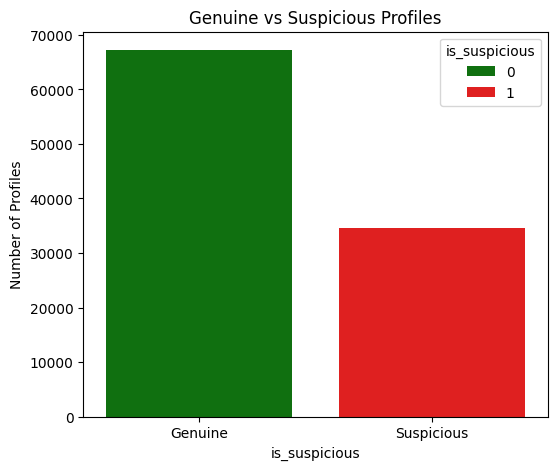

In [4]:
plt.figure(figsize=(6,5))
sns.countplot(data=data,x='is_suspicious',palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Genuine vs Suspicious Profiles')
plt.ylabel('Number of Profiles')
plt.show()

##### Suspicion Tier Breakdown

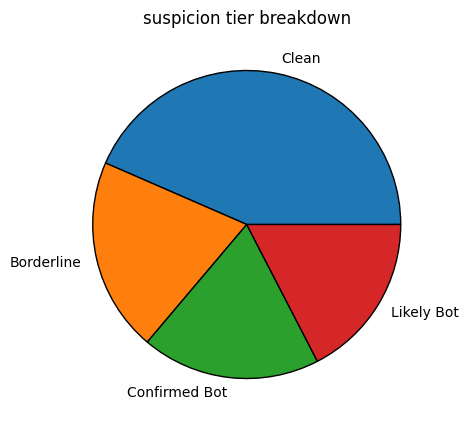

In [5]:
tier_counts=data['suspicion_tier'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(tier_counts,labels=tier_counts.index,wedgeprops={'edgecolor':'black','linewidth':1})
plt.title('suspicion tier breakdown')
plt.show()

##### Average README Score

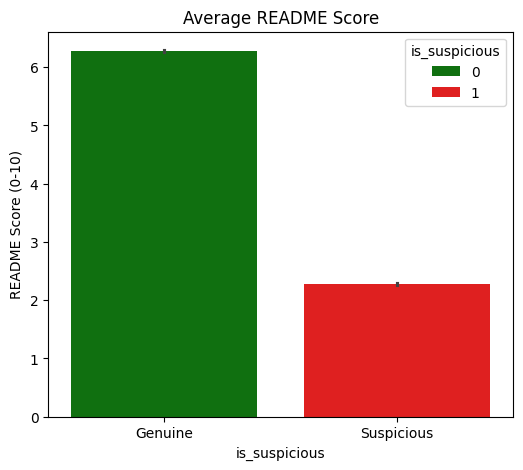

In [6]:
plt.figure(figsize=(6,5))
sns.barplot(data=data,x='is_suspicious',y='readme_score',palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1], ['Genuine','Suspicious'])
plt.title('Average README Score')
plt.ylabel('README Score (0-10)')
plt.show()

##### Stars vs Forks

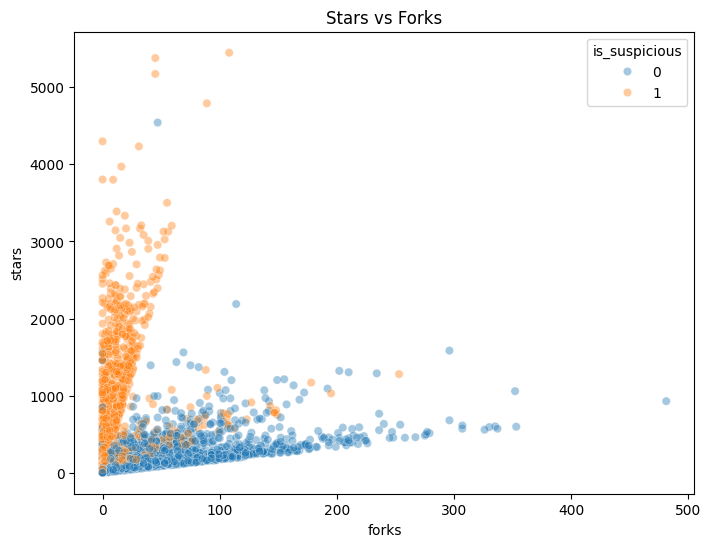

In [7]:
sample = data.sample(5000)

plt.figure(figsize=(8,6))
sns.scatterplot(data=sample,x='forks',y='stars',hue='is_suspicious',alpha=0.4)
plt.title('Stars vs Forks')
plt.show()

##### README Score Distribution

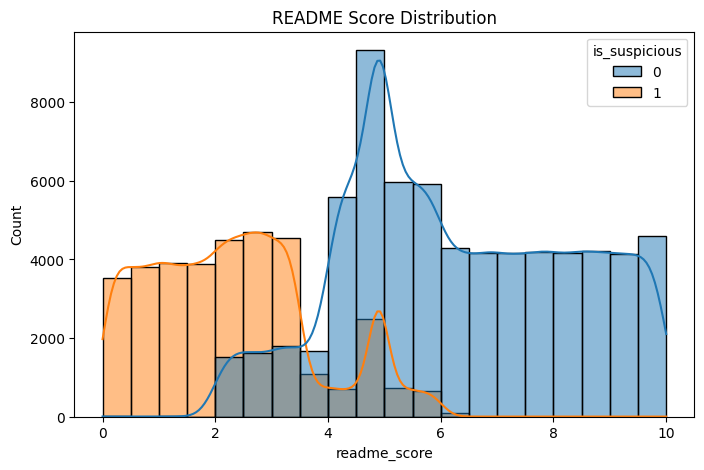

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='readme_score', hue='is_suspicious',kde=True,bins=20)
plt.title('README Score Distribution')
plt.show()

#####  README Score by Suspicion Tier 

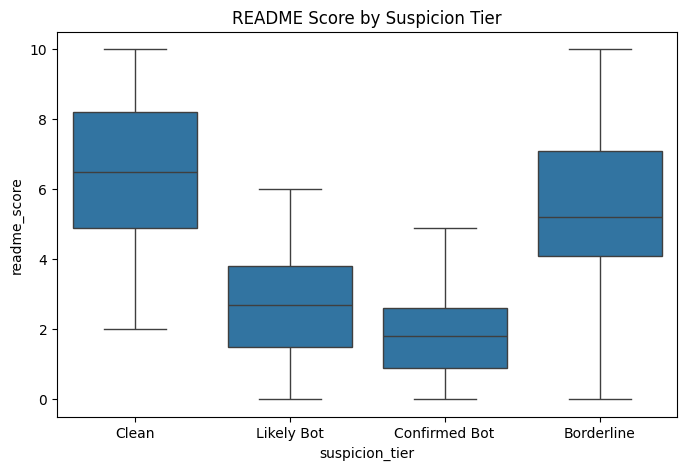

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='suspicion_tier', y='readme_score')
plt.title('README Score by Suspicion Tier')
plt.show()

##### Commit Streak Distribution

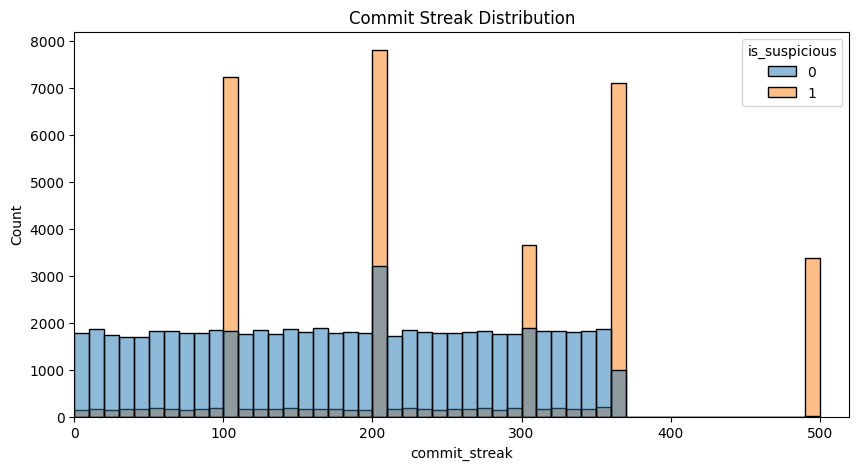

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x='commit_streak', hue='is_suspicious', bins=50)
plt.xlim(0, 520)
plt.title('Commit Streak Distribution')
plt.show()

##### Average Follow Ratio

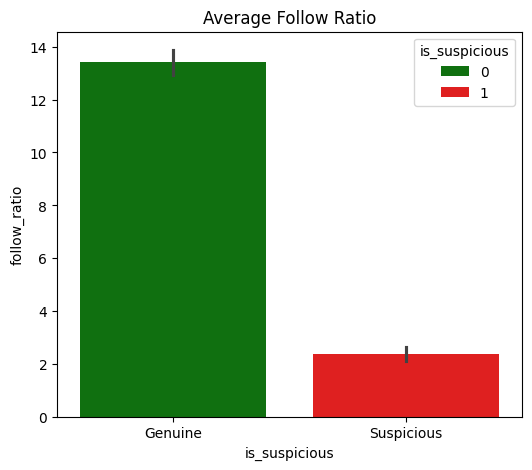

In [11]:
plt.figure(figsize=(6,5))
sns.barplot(data=data, x='is_suspicious', y='follow_ratio', palette=['green','red'],hue='is_suspicious')
plt.xticks([0,1], ['Genuine','Suspicious'])
plt.title('Average Follow Ratio')
plt.show()

#####  Followers vs Following

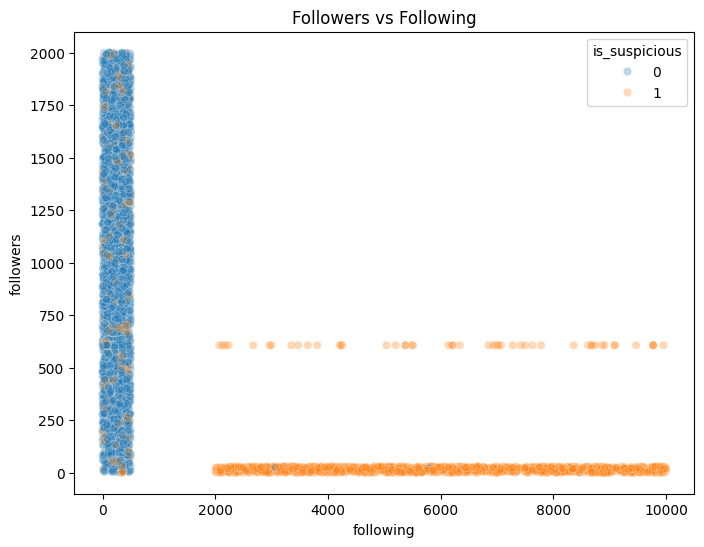

In [12]:
sample2=data.sample(5000,random_state=7)

plt.figure(figsize=(8,6))
sns.scatterplot(data=sample2, x='following', y='followers', hue='is_suspicious',alpha=0.3)
plt.title('Followers vs Following')
plt.show()

##### Suspicion Rate by Language

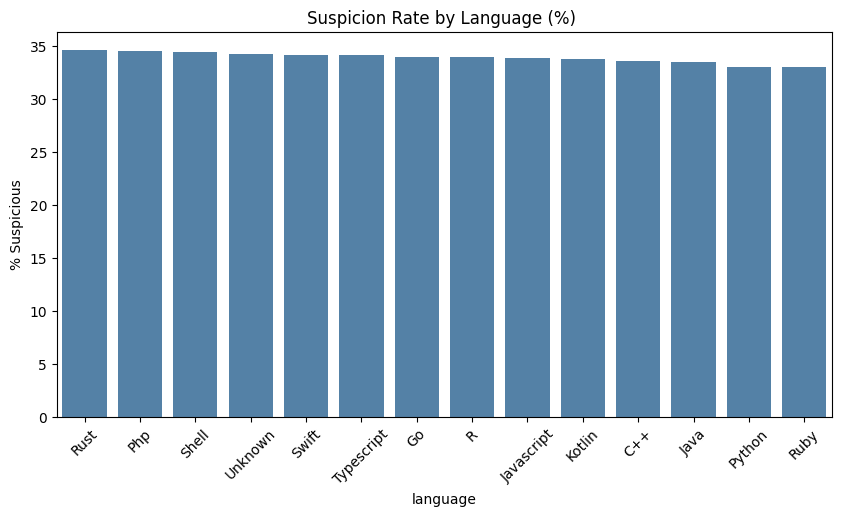

In [13]:
lang_counts=data['language'].value_counts()
valid=lang_counts[lang_counts>=500].index
filtered=data[data['language'].isin(valid)]

lang_sus=filtered.groupby('language')['is_suspicious'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(10,5))
sns.barplot(x=lang_sus.index, y=lang_sus.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Suspicion Rate by Language (%) ')
plt.ylabel('% Suspicious')
plt.show()

##### Top 10 Countries by Profile Count

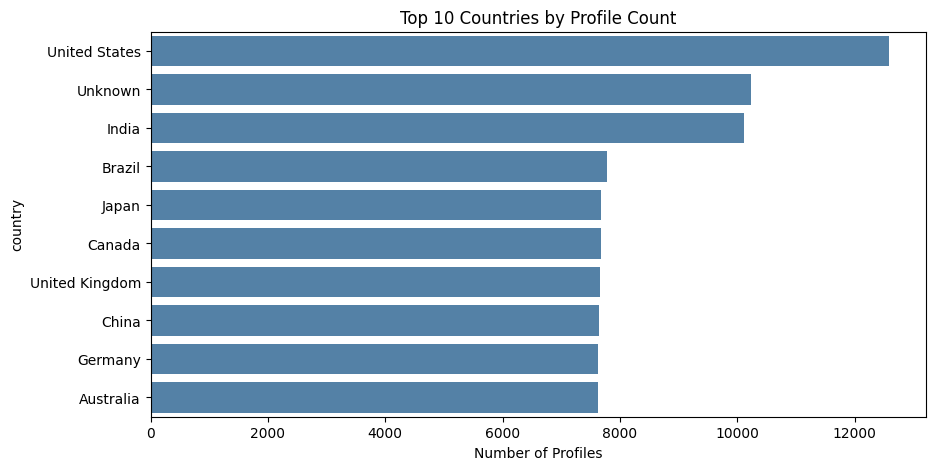

In [14]:
top_countries=data['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, color='steelblue')
plt.title('Top 10 Countries by Profile Count')
plt.xlabel('Number of Profiles')
plt.show()

##### Suspicion Rate by Account Age

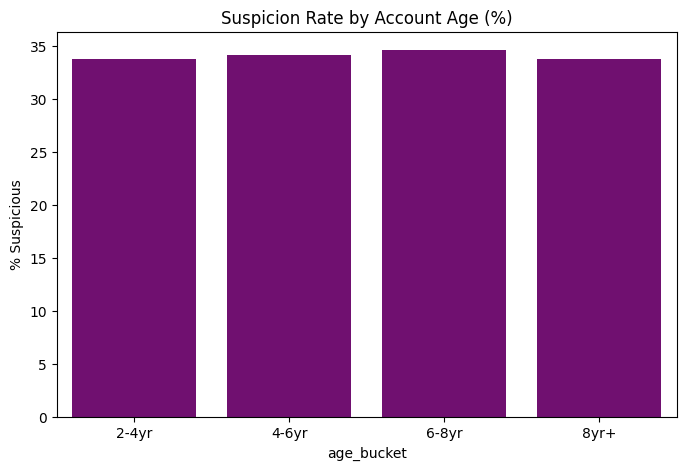

In [15]:
age_sus=data.groupby('age_bucket')['is_suspicious'].mean()*100

plt.figure(figsize=(8,5))
sns.barplot(x=age_sus.index, y=age_sus.values, color='purple')
plt.title('Suspicion Rate by Account Age (%)')
plt.ylabel('% Suspicious')
plt.show()

##### Suspicion Rate by Commit Frequency

C:\Users\attil\AppData\Local\Temp\ipykernel_2340\4208894352.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq_sus.index, y=freq_sus.values, palette=['green','orange','red'])


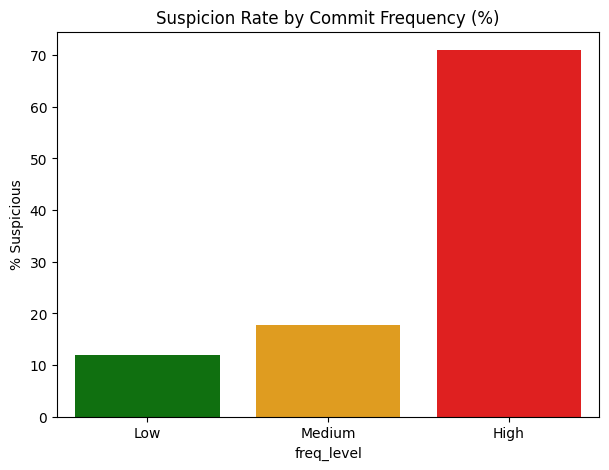

In [16]:
freq_sus = data.groupby('freq_level')['is_suspicious'].mean().reindex(['Low','Medium','High']) * 100

plt.figure(figsize=(7,5))
sns.barplot(x=freq_sus.index, y=freq_sus.values, palette=['green','orange','red'])
plt.title('Suspicion Rate by Commit Frequency (%)')
plt.ylabel('% Suspicious')
plt.show()

##### Correlation Heatmap

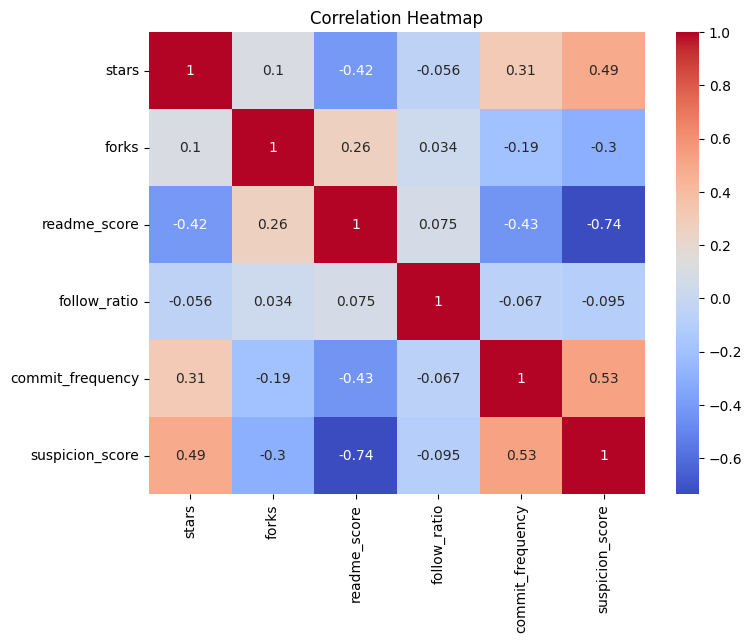

In [17]:
cols=['stars','forks','readme_score','follow_ratio','commit_frequency','suspicion_score']
plt.figure(figsize=(8,6))
sns.heatmap(data[cols].corr(),annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### README score by Suspicion Tier

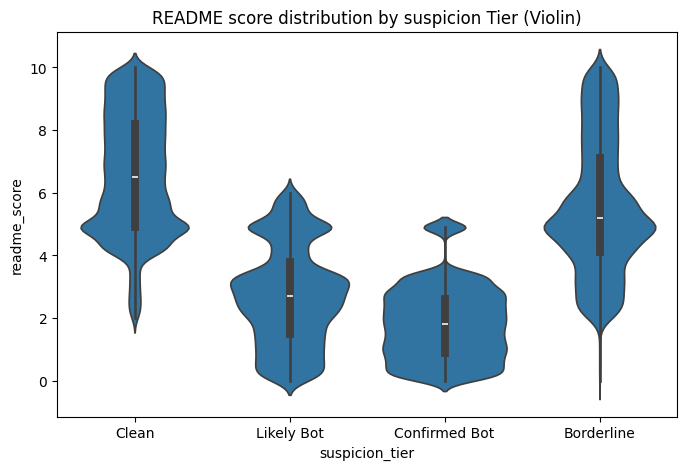

In [18]:
plt.figure(figsize=(8,5))
sns.violinplot(data=data, x='suspicion_tier', y='readme_score')
plt.title('README score distribution by suspicion Tier (Violin)')
plt.show()

##### Follow Ratio Spread

In [ ]:
sample3=data.sample(100.random_state=42)
plt.figure(figsize=(7,5))
sns.stripplot(data=sample3, x='is_suspicious', y='follow_ratio', alpha=0.5)
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Follow Ratio - Individual Profiles')

plt.show()

##### README score Spread

In [ ]:
sample4=data.sample(100.random_state=42)

plt.figure(figsize=(7,5))
sns.swarmplot(data=sample4, x='is_suspicious', y='readme_score', alpha=0.5)
plt.xticks([0,1],['Genuine','Suspicious'])
plt.title('Readme Score - Individual Profiles')

plt.show()

##### README score vs Suspicion Score

In [ ]:
sample5=data.sample(100.random_state=42)

plt.figure(figsize=(8,5))
sns.regplot(data=sample5,x='readme_score', y='suspicion_score', scatter_kws={'alpha':0.2})
plt.title('README score vs Suspicion Score (with trend line) ')
plt.show()